In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

In [2]:
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

from sklearn.neighbors import KernelDensity
from astroML.linear_model import NadarayaWatson

(35.0, 50.0)

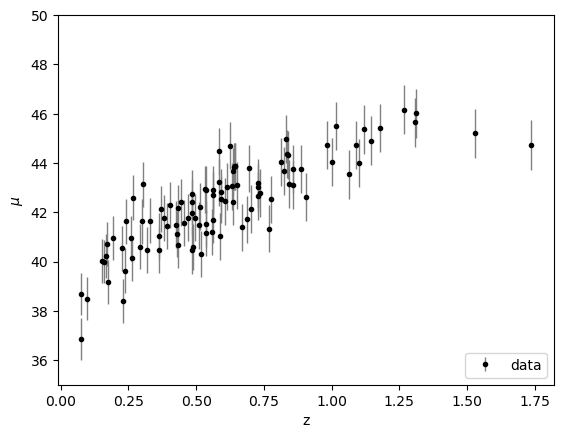

In [4]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [5]:
X = z_sample[:, np.newaxis]
y = mu_sample
dy = dmu

In [44]:
from sklearn.gaussian_process import GaussianProcessRegressor


gp = GaussianProcessRegressor()
gp.fit(X,y)
y_pred, dy_pred = gp.predict(X, return_std=True)

In [7]:
#w/o picking a specific kernel
gp3 = GaussianProcessRegressor()
gp3.fit(X,y)
linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

In [28]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
length_scale = 0.5

kernel3 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp3 = GaussianProcessRegressor(kernel=kernel3,
                               alpha=dy3**2,
                               random_state=0)
gp3.fit(X,y)
linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

(35.0, 50.0)

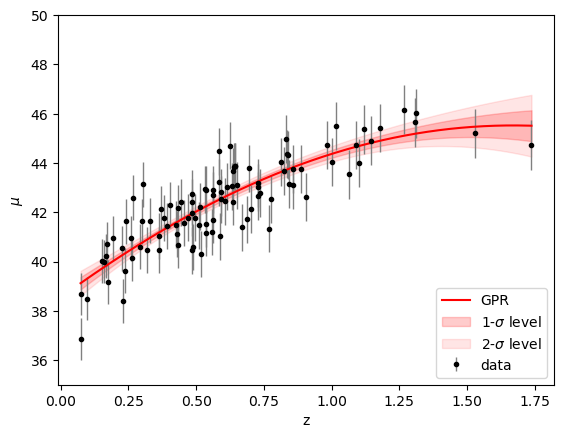

In [29]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#plt.errorbar(z_sample, y_pred, dy_pred, fmt='.r', ecolor='gray', lw=1,label='GPR')
plt.plot(linx, y_predx, color='r', label='GPR')
plt.fill_between(linx[:,0], y_predx - dy_predx, y_predx + dy_predx, color='r', alpha=0.2, label='1-$\sigma$ level')
plt.fill_between(linx[:,0], y_predx - 2*dy_predx, y_predx + 2*dy_predx, color='r', alpha=0.1, label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

(35.0, 50.0)

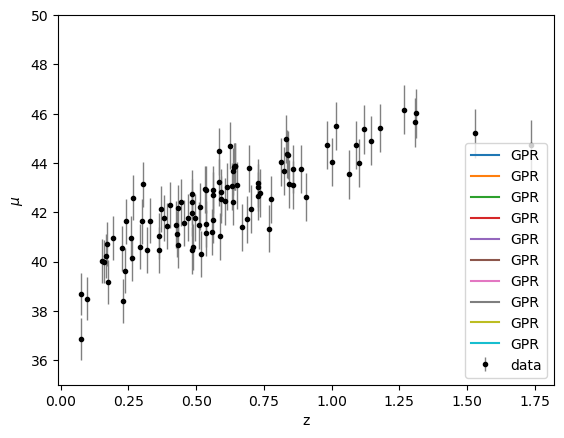

In [30]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
lscales = np.logspace(-3,3,10)
for ls in lscales:

    kernel3 = ConstantKernel(1.0, (1e-3, 1e3))*kernels.RBF(ls, (0.01, 100.0))
    gp4 = GaussianProcessRegressor(kernel=kernel3,
                                   alpha=dy3**2,
                                   random_state=0)
    gp3.fit(X,y)
    linx = np.linspace(min(z_sample),max(z_sample),10000)[:, np.newaxis]
    y_predx, dy_predx = gp4.predict(linx, return_std=True)
    
    
    plt.plot(linx, y_predx, label='GPR')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [45]:
#I should cross validate!!!!!! I need to find the best kernel (this one has two parameters, so how?)

In [31]:
z_vals = np.array(z_sample).reshape(-1, 1) 
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

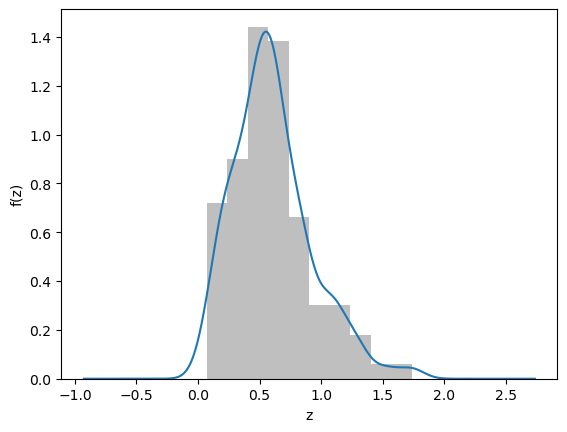

In [43]:
z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)
plt.hist(z_sample, color='gray',alpha=0.5,label='data',density=True)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('f(z)')
plt.show()

Text(0.5, 1.0, 'Cloned data')

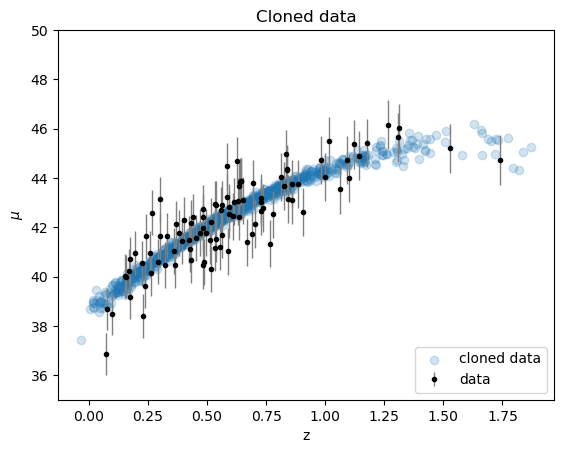

In [27]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp3.predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.2,label='cloned data')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)
plt.title("Cloned data")